In [39]:
import numpy as np
import matplotlib.pyplot as plt

Making a circle and some points on it.

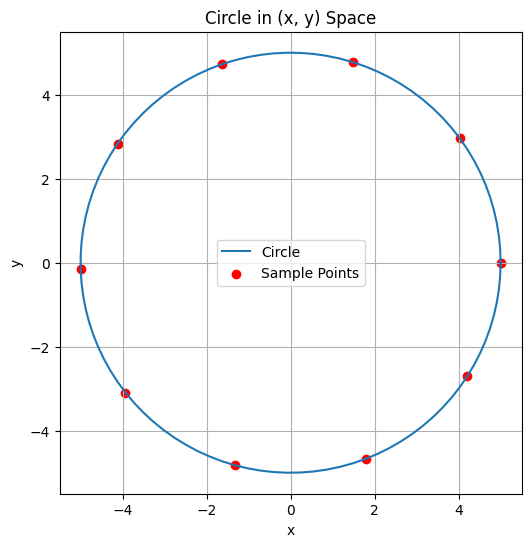

In [40]:
import matplotlib.pyplot as plt
import numpy as np

h, k = 0, 0
radius = 5
angle = np.linspace(0, 2 * np.pi, 100)
x = h + radius * np.cos(angle)
y = k + radius * np.sin(angle)

plt.figure(figsize=(6, 6))
plt.plot(x, y, label='Circle')
plt.scatter(x[::10], y[::10], color='red', label='Sample Points')
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Circle in (x, y) Space')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

changing the x , y points to a , b points using the circle equation.

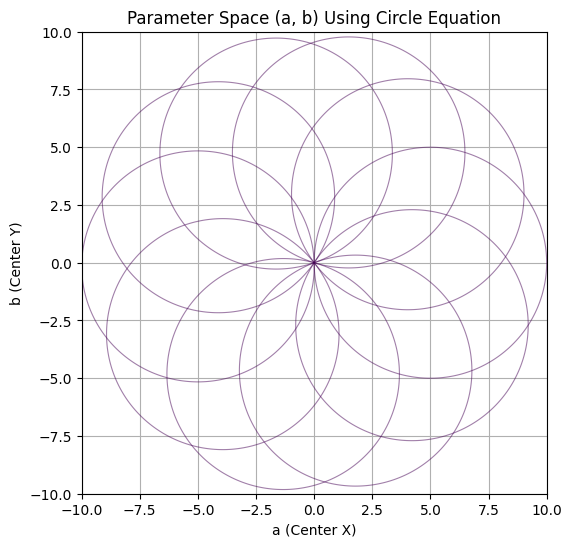

In [41]:
A = np.linspace(-10, 10, 200)
B = np.linspace(-10, 10, 200)
A, B = np.meshgrid(A, B)

plt.figure(figsize=(6, 6))
for x_point, y_point in zip(x[::10], y[::10]):
    curve = (A - x_point)**2 + (B - y_point)**2 - radius**2
    plt.contour(A, B, curve, levels=[0], alpha=0.5, linewidths=0.8, cmap='viridis')

plt.title('Parameter Space (a, b) Using Circle Equation')
plt.xlabel('a (Center X)')
plt.ylabel('b (Center Y)')
plt.grid(True)
plt.show()


The point all circles crossing is the a , b cordinate.

In [42]:
import cv2

In [43]:
image = cv2.imread("D:\Computer-Vision\Image-Processing\HoughTransform\coin.jpg")

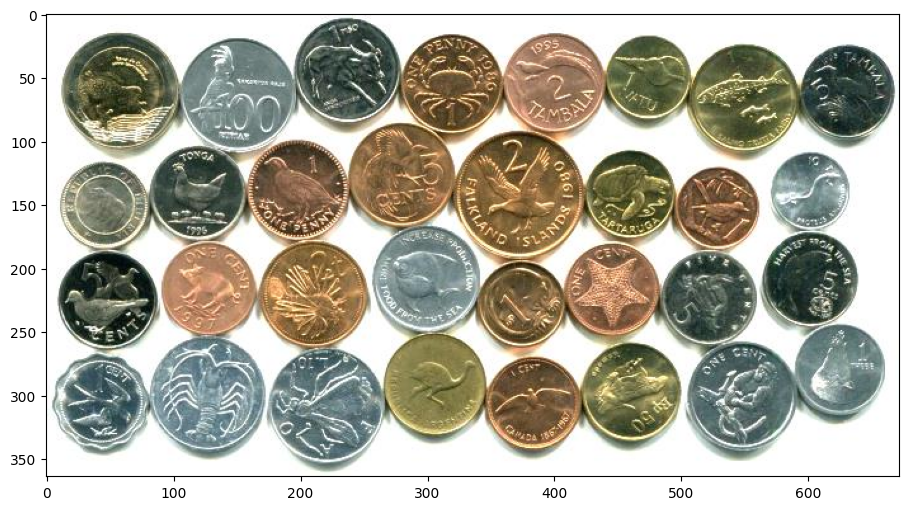

In [44]:
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

Gets blured with gaussian blur filter (5,5) >>> we have circle edges inside the coins + outside edge of coin. we have to gets soft and smooth the edges for did not detect the inside edges of coins.

In [45]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 1.5)

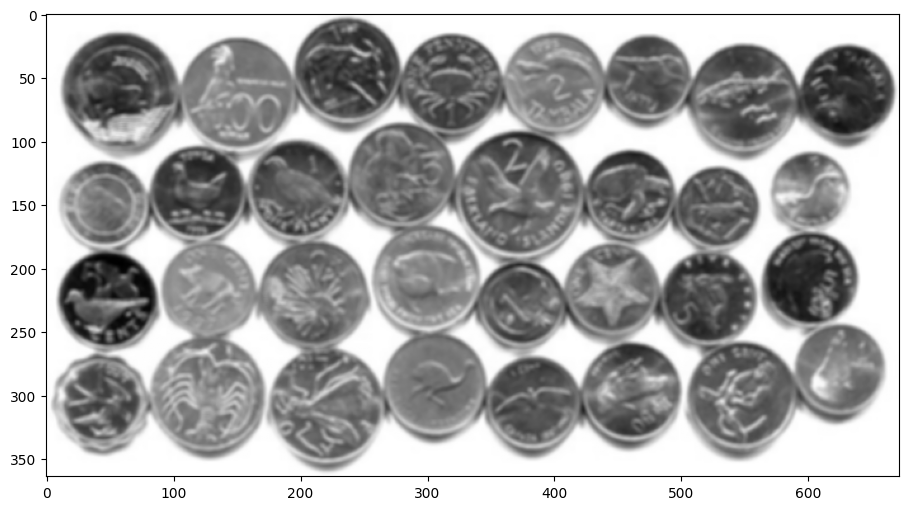

In [46]:
plt.figure(figsize=(12,6))
plt.imshow(blur,cmap='gray')
plt.show()

We dont use Canny because of that H-C have it in itself.

In [47]:
circles1 = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, dp=1, minDist=40, param1=150, param2=50, minRadius=20, maxRadius=60)

In [48]:
circles1

array([[[151.5,  61.5,  42.7],
        [549.5,  66.5,  42.7],
        [460.5, 299.5,  40.5],
        [319.5,  54.5,  39.4],
        [371.5, 141.5,  49.5],
        [220.5, 308.5,  44.9],
        [ 58.5,  59.5,  44.9],
        [198.5, 136.5,  37.2],
        [625.5, 279.5,  35.8],
        [459.5, 141.5,  34.9],
        [237.5,  44.5,  41.8],
        [602.5, 207.5,  35.9],
        [305.5, 290.5,  39.4],
        [473.5,  49.5,  32.7],
        [127.5, 297.5,  42.7],
        [522.5, 223.5,  37.2],
        [300.5, 210.5,  43.8],
        [447.5, 220.5,  40.5],
        [118.5, 138.5,  35.1],
        [279.5, 126.5,  40.5],
        [385.5, 304.5,  34.9],
        [528.5, 151.5,  30.8],
        [208.5, 222.5,  44.9],
        [547.5, 300.5,  38.1],
        [ 49.5, 225.5,  39.4],
        [400.5,  53.5,  38.3],
        [373.5, 228.5,  29.6],
        [631.5,  59.5,  35. ],
        [ 42.5, 150.5,  32.5],
        [125.5, 217.5,  39.4],
        [601.5, 137.5,  29.7],
        [ 45.5, 302.5,  33.8]]], dtype=

In [49]:
image_circles1 = image.copy()
if circles1 is not None:
    circles1 = np.round(circles1[0, :]).astype("int")
    for (x, y, r) in circles1:
        cv2.circle(image_circles1, (x, y), r, (0, 0, 255), 2)

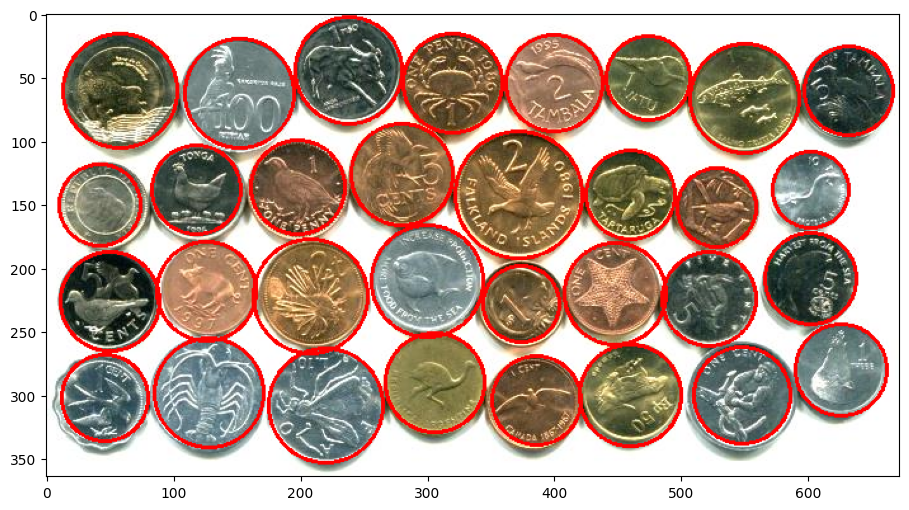

In [50]:
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(image_circles1, cv2.COLOR_BGR2RGB))
plt.show()

In [51]:
# HOUGH_GRADIENT_ALT

In [73]:
circles2 = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT_ALT, dp=1, minDist=40, param1=150, param2=0.9, minRadius=30, maxRadius=100)

In [74]:
image_circles2 = image.copy()
if circles2 is not None:
    circles2 = np.round(circles2[0, :]).astype("int")
    for (x, y, r) in circles2:
        cv2.circle(image_circles2, (x, y), r, (0, 0, 255), 2)

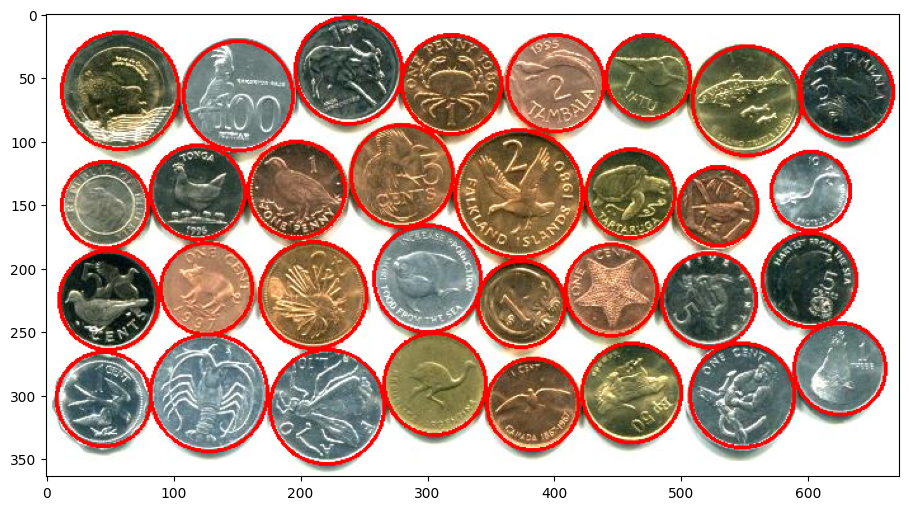

In [75]:
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(image_circles2, cv2.COLOR_BGR2RGB))
plt.show()

In [55]:
image_circles3 = image.copy()
image_circles3 = cv2.circle(image_circles3, (150, 150), 100, (255, 0, 0), 2)

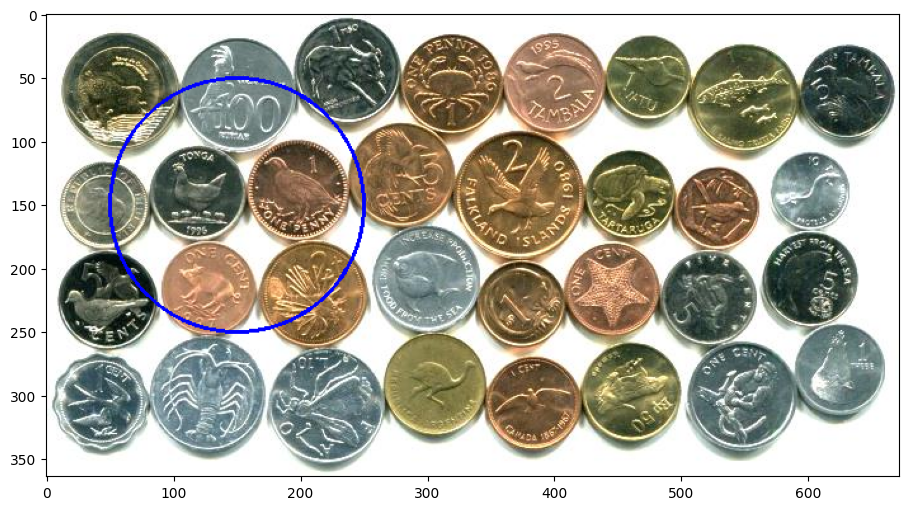

In [56]:
plt.figure(figsize=(12,6))
plt.imshow(cv2.cvtColor(image_circles3, cv2.COLOR_BGR2RGB))
plt.show()